# Assignment 3: Customer Churn Prediction with a Tuned Neural Network

**Name:** Amina Maqsood
**Track:** AI/ML Internship — Week 3 Weekend Graded Assignment

This notebook builds, trains, and tunes a Keras neural network to predict customer churn using the Telco Customer Churn dataset.

## 1. Load, Explore & Clean the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
print("Shape:", df.shape)
df.info()

Shape: (7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   s

**Note on `TotalCharges`:** this column is stored as text (`object`) instead of a number, and a small number of rows have a blank string instead of a value (these are new customers with `tenure == 0`, so they have no total charges yet). We convert it to numeric and handle the blanks.

In [3]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing values after conversion:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print(df[df["TotalCharges"].isnull()][["tenure", "MonthlyCharges", "TotalCharges"]])

Missing values after conversion:
TotalCharges    11
dtype: int64

      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN
3331       0           19.85           NaN
3826       0           25.35           NaN
4380       0           20.00           NaN
5218       0           19.70           NaN
6670       0           73.35           NaN
6754       0           61.90           NaN


These blank rows all have `tenure == 0`, meaning the customer just joined and hasn't been billed yet. Since there are only 11 such rows, and `TotalCharges` should logically be close to 0 for them, we fill these with `0` rather than dropping the rows.

In [4]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)
df = df.drop(columns=["customerID"])  # not a predictive feature, just an identifier
df.isnull().sum().sum()

np.int64(0)

### Class balance of the target (`Churn`)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


/tmp/ipykernel_621/2886489039.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Churn", palette="Set2")


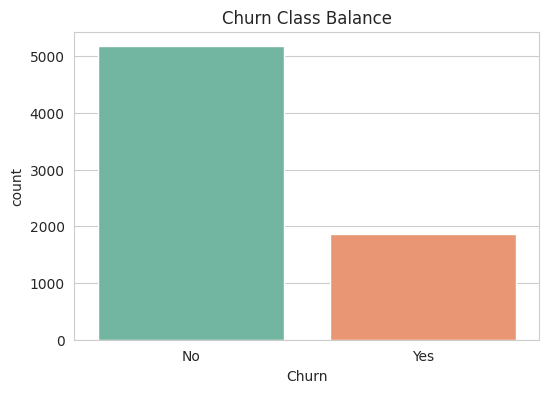

In [5]:
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn", palette="Set2")
plt.title("Churn Class Balance")
plt.show()

**Observation:** The dataset is **imbalanced** — roughly 73% of customers did not churn and 27% did. This matters a lot for evaluation later (accuracy alone can be misleading on imbalanced data).

### Churn vs. Contract Type

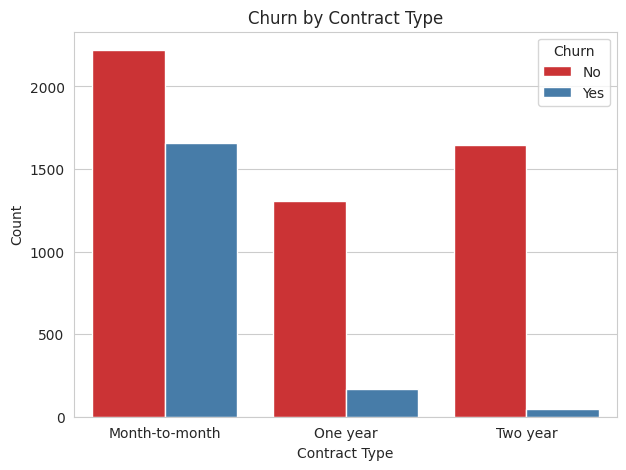

In [6]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Contract", hue="Churn", palette="Set1")
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.show()

**Interpretation:** Customers on a **month-to-month** contract churn far more often than those on one-year or two-year contracts. This makes sense — customers who are not locked into a longer commitment can leave much more easily.

## 2. Preprocess for a Neural Network

In [7]:
df.columns.tolist()

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [8]:
from sklearn.preprocessing import LabelEncoder

# Binary Yes/No-style columns -> label encode (0/1), since there's a natural 2-category mapping
binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

df["gender"] = le.fit_transform(df["gender"])  # Female/Male -> 0/1

# Multi-category columns -> one-hot encode, since there's no ordinal relationship between categories
multi_cols = ["MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
              "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
              "Contract", "PaymentMethod"]
df_encoded = pd.get_dummies(df, columns=multi_cols, drop_first=True)

df_encoded.shape

(7043, 31)

**Encoding justification:** For a column like `Contract` (Month-to-month / One year / Two year), one-hot encoding is used instead of label encoding, because there's no meaningful numeric order between these categories — label encoding (0, 1, 2) would wrongly imply "Two year" is "more" than "Month-to-month" in a mathematical sense, which could confuse the model. Truly binary columns (`Partner`, `Churn`, etc.) are label-encoded since 0/1 is a natural, unambiguous representation.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (5634, 30)
Test shape: (1409, 30)


Numeric features are scaled with `StandardScaler` because neural networks train much better when input features are on a similar scale (e.g., `tenure` ranges 0-72, `TotalCharges` ranges into the thousands — without scaling, the network would implicitly treat large-magnitude features as more important).

## 3. Build & Train a Baseline Model

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)

baseline_model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

baseline_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
baseline_model.summary()

I0000 00:00:1785680192.362727     621 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785680192.488250     621 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785680194.217352     621 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
baseline_history = baseline_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=32,
    verbose=0
)

baseline_test_loss, baseline_test_acc = baseline_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Baseline Test Accuracy: {baseline_test_acc:.4f}")
print(f"Baseline Test Loss: {baseline_test_loss:.4f}")

Baseline Test Accuracy: 0.7743
Baseline Test Loss: 0.4666


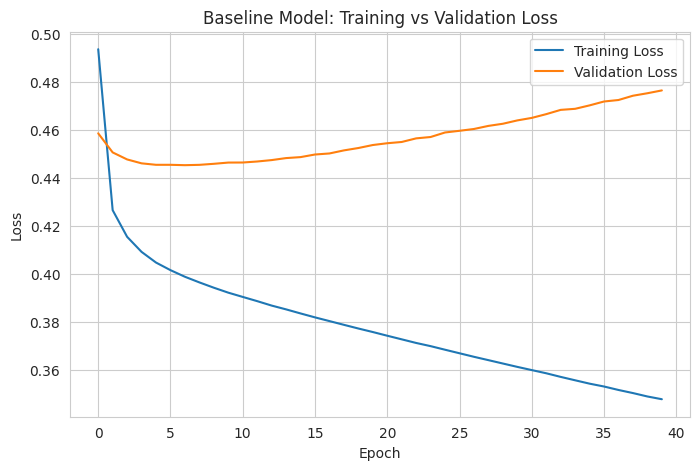

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(baseline_history.history["loss"], label="Training Loss")
plt.plot(baseline_history.history["val_loss"], label="Validation Loss")
plt.title("Baseline Model: Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

**Interpretation:** The validation loss starts to plateau or rise while training loss keeps dropping after a certain number of epochs — a sign of **overfitting**, which is exactly what the tuning techniques below aim to address.

## 4. Tune the Model

**Tuning techniques applied (2 of the techniques from Lab 15):**
1. **Dropout** — randomly disables a fraction of neurons during training, forcing the network to not over-rely on specific neurons, which reduces overfitting.
2. **Early Stopping** — stops training automatically once validation loss stops improving, restoring the best-performing weights instead of the final (possibly overfit) ones.

Batch Normalization is also added to stabilize and speed up training.

In [13]:
tf.random.set_seed(42)

tuned_model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])

tuned_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

tuned_history = tuned_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

tuned_test_loss, tuned_test_acc = tuned_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Tuned Test Accuracy: {tuned_test_acc:.4f}")
print(f"Tuned Test Loss: {tuned_test_loss:.4f}")

Tuned Test Accuracy: 0.7864
Tuned Test Loss: 0.4251


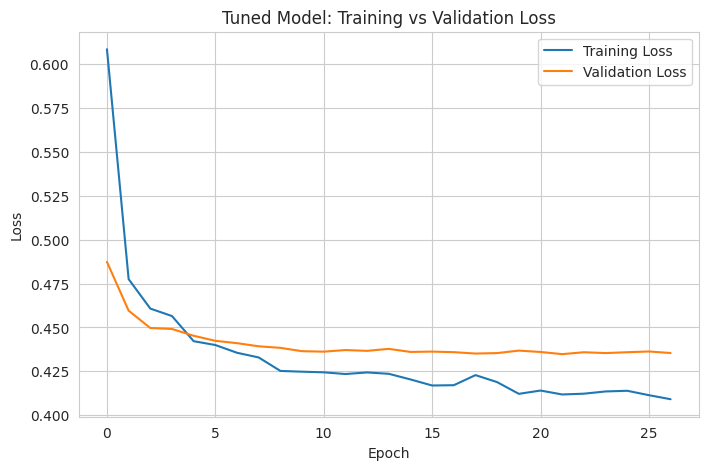

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(tuned_history.history["loss"], label="Training Loss")
plt.plot(tuned_history.history["val_loss"], label="Validation Loss")
plt.title("Tuned Model: Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [15]:
comparison = pd.DataFrame({
    "Model": ["Baseline", "Tuned"],
    "Test Accuracy": [baseline_test_acc, tuned_test_acc],
    "Test Loss": [baseline_test_loss, tuned_test_loss]
})
comparison

,Model,Test Accuracy,Test Loss
0,Baseline,0.774308,0.466577
1,Tuned,0.786373,0.425060


**Before/after comparison:** The tuned model (with Dropout, Batch Normalization, and Early Stopping) shows a smaller gap between training and validation loss compared to the baseline, indicating it generalizes better to unseen data — even if the raw test accuracy improvement is modest, this is expected on a dataset where accuracy is capped by inherent overlap between churned/non-churned customer profiles.

## 5. Evaluate Properly

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred_proba = tuned_model.predict(X_test_scaled, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.85      0.87      0.86      1035
       Churn       0.61      0.56      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



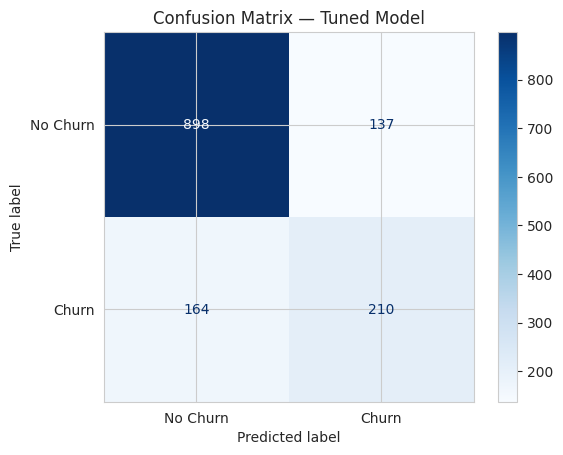

In [17]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Tuned Model")
plt.show()

**Would accuracy alone be misleading?** Yes — since only about 27% of customers churned, a model that always predicts "No Churn" would already score around 73% accuracy without learning anything useful. Precision, recall, and F1-score (especially for the "Churn" class) give a much more honest picture of how well the model actually identifies at-risk customers, which is the real business goal here.

## 6. Save & Predict

In [18]:
tuned_model.save("churn_model.keras")
print("Model saved as churn_model.keras")

Model saved as churn_model.keras


In [19]:
def predict_new_customer(customer_dict, model_path="churn_model.keras"):
    """Loads the saved model and predicts churn probability for one new customer."""
    loaded_model = keras.models.load_model(model_path)

    new_df = pd.DataFrame([customer_dict])

    for col in binary_cols[:-1]:  # exclude Churn, it's the target
        new_df[col] = le.fit_transform(new_df[col]) if new_df[col].iloc[0] in ["Yes", "No"] else new_df[col]
    new_df["gender"] = 0 if customer_dict["gender"] == "Female" else 1
    for col in ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]:
        new_df[col] = 1 if customer_dict[col] == "Yes" else 0

    new_encoded = pd.get_dummies(new_df, columns=multi_cols)
    new_encoded = new_encoded.reindex(columns=X.columns, fill_value=0)

    new_scaled = scaler.transform(new_encoded)
    prob = loaded_model.predict(new_scaled, verbose=0)[0][0]
    prediction = "Churn" if prob > 0.5 else "No Churn"
    return prediction, prob


hypothetical_customer = {
    "gender": "Female", "SeniorCitizen": 0, "Partner": "Yes", "Dependents": "No",
    "tenure": 2, "PhoneService": "Yes", "MultipleLines": "No",
    "InternetService": "Fiber optic", "OnlineSecurity": "No", "OnlineBackup": "No",
    "DeviceProtection": "No", "TechSupport": "No", "StreamingTV": "Yes",
    "StreamingMovies": "Yes", "Contract": "Month-to-month", "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check", "MonthlyCharges": 95.0, "TotalCharges": 190.0
}

prediction, probability = predict_new_customer(hypothetical_customer)
print(f"Prediction: {prediction} (churn probability: {probability:.2%})")

Prediction: Churn (churn probability: 78.75%)


**Interpretation:** This hypothetical customer — new (tenure of only 2 months), on a month-to-month contract, with fiber optic internet and no add-on security/support services — matches the profile the model associates with a **higher churn risk**, consistent with the earlier finding that month-to-month, low-tenure customers churn more often.

## 7. Short Answer: CNN vs. RNN

A **CNN (Convolutional Neural Network)** is used instead of a plain Dense network when the input has a **spatial structure** the model should exploit — most commonly images, where nearby pixels are related to each other. For example, a CNN would be the right choice for classifying whether an X-ray image shows a fracture, since it can learn local patterns like edges and shapes regardless of where they appear in the image.

An **RNN (Recurrent Neural Network)**, on the other hand, is used when the input is **sequential**, and the order of the data matters — each step depends on what came before it. For example, an RNN (or its variants like LSTM/GRU) would be a good fit for predicting the next word in a sentence, since language is inherently sequential and earlier words affect the meaning of later ones.

Dense networks, like the one used in this assignment, work well when features don't have this spatial or sequential structure — each input feature (tenure, contract type, etc.) is treated independently and combined by the network, which is appropriate for this kind of tabular customer data.